# Inspect the Phase 1 latent prior (v8)

Sanity-checks for whether the v8 prior at `checkpoints/latent_prior_v8/best/` is good enough to drive Phase 2.

Sections:
1. **Load** encoder + predictor + normalizer from the ckpt dir.
2. **Latent organization** — how do the 6 behaviors arrange themselves in latent space (PCA + per-class spread, t-SNE, between/within variance)?
3. **Reconstruction quality** — per-frame MSE, per-active-dim breakdown.
4. **Predictor quality** — single-step vs autoregressive rollout.
5. **Rendering** — side-by-side and ghost-overlay videos for reconstruction and prediction. Saved into `latent_prior_v8/best/renders/` and embedded inline.

All renders write into the ckpt directory so they're co-located with the artifacts that produced them.

## 0. Setup

In [1]:
import os, sys
from pathlib import Path

# Use EGL for offscreen MuJoCo rendering BEFORE importing mujoco.
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")

REPO = Path("/home/talmolab/Desktop/SalkResearch/track-mjx")
VNL = Path("/home/talmolab/Desktop/SalkResearch/vnl-playground")
for p in (REPO, VNL):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import h5py
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import serialization
from omegaconf import OmegaConf

from track_mjx.agent.latent_ppo.data.frame_features import (
    MOTION_FRAME_DIM,
    extract_motion_frames,
)
from track_mjx.agent.latent_ppo.networks.encoder import (
    MotionEncoder,
    MotionEncoderConv1D,
)
from track_mjx.agent.latent_ppo.networks.decoder import MotionDecoder
from track_mjx.agent.latent_ppo.networks.predictor import MotionPredictor
from track_mjx.agent.latent_ppo.prior_module import FrozenLatentPrior
from vnl_playground.tasks.reference_clips import ReferenceClips

# === paths ===
CKPT_DIR = REPO / "checkpoints" / "latent_prior_v8" / "best"
DATA_PATH = REPO / "data" / "rodent" / "rodent_reference_clips.h5"
RAT_XML = "/home/talmolab/Desktop/SalkResearch/stac-mjx/models/rodent.xml"
RENDER_DIR = CKPT_DIR / "renders"
RENDER_DIR.mkdir(parents=True, exist_ok=True)
print(f"CKPT: {CKPT_DIR}")
print(f"DATA: {DATA_PATH}")
print(f"RENDER: {RENDER_DIR}")

CKPT: /home/talmolab/Desktop/SalkResearch/track-mjx/checkpoints/latent_prior_v8/best
DATA: /home/talmolab/Desktop/SalkResearch/track-mjx/data/rodent/rodent_reference_clips.h5
RENDER: /home/talmolab/Desktop/SalkResearch/track-mjx/checkpoints/latent_prior_v8/best/renders


## 1. Load the prior + dataset

In [2]:
prior = FrozenLatentPrior.from_dir(CKPT_DIR)
cfg = OmegaConf.load(CKPT_DIR / "config.yaml")
print(f'encoder_type:  {cfg.get("encoder_type", "mlp")}')
print(f"use_qvel:      {prior.use_qvel}")
print(f"n_joints:      {prior.n_joints}")
print(f"feat_dim:      {prior.feat_dim}")
print(f"window_len:    {prior.window_len}")
print(f"horizon:       {prior.horizon}")
print(f"latent_dim:    {prior.latent_dim}")

# Reference clips (842 × 250 × 74) and behavior labels (6 classes).
clips = ReferenceClips(str(DATA_PATH), n_frames_per_clip=cfg.clip_length)
motion_all = extract_motion_frames(
    clips, n_joints=prior.n_joints, use_qvel=prior.use_qvel
)
behavior = np.array(list(clips.clip_names))
print(f"\nmotion: {motion_all.shape}")
print(f"behaviors: {sorted(set(behavior))}")
from collections import Counter

for b, c in Counter(behavior).most_common():
    print(f"  {b:12s}: {c} clips")

encoder_type:  conv1d
use_qvel:      False
n_joints:      67
feat_dim:      74
window_len:    10
horizon:       5
latent_dim:    60

motion: (842, 250, 74)
behaviors: [np.str_('FaceGroom'), np.str_('FastWalk'), np.str_('LGroom'), np.str_('RGroom'), np.str_('Rear'), np.str_('Walk')]
  FastWalk    : 189 clips
  Walk        : 174 clips
  Rear        : 165 clips
  FaceGroom   : 136 clips
  RGroom      : 96 clips
  LGroom      : 82 clips


In [3]:
# Active-dim mask (zero-variance dead dims like caudal vertebrae / fingers / mandible).
raw_std = np.load(CKPT_DIR / "normalizer.npz")["std"]
active_mask = (raw_std > 1e-3).astype(np.float32)
n_active = int(active_mask.sum())
print(
    f'active dims: {n_active}/{prior.feat_dim}  (the rest are zero-variance "dead" channels)'
)

active dims: 45/74  (the rest are zero-variance "dead" channels)


## 2. Latent space organization

Encode every window from every clip, color by behavior, look at:
- per-dim activity of `μ` across windows (any dead latents?)
- posterior `σ` (how tight is the encoder)
- between-class vs within-class variance ratio
- PCA of `μ` + scatter colored by behavior
- t-SNE for fine-grained structure

In [4]:
@jax.jit
def _encode(params_e, x):
    return prior.encoder.apply(params_e, prior.normalize(x))


w = prior.window_len
n_anchors_per_clip = motion_all.shape[1] - w
# For latent organization analysis, sample one window every 25 frames per clip
# (10 windows per clip * 842 clips = 8420 total — fast t-SNE)
stride = 25
anchors = np.arange(0, n_anchors_per_clip, stride)

z_means_all = []
z_stds_all = []
labels = []
for clip_i in range(motion_all.shape[0]):
    clip = motion_all[clip_i]
    wins = np.stack([clip[a : a + w] for a in anchors], 0)
    m, lv = _encode(prior.enc_params, jnp.asarray(wins))
    z_means_all.append(np.asarray(m))
    z_stds_all.append(np.asarray(jnp.exp(0.5 * lv)))
    labels.extend([behavior[clip_i]] * len(anchors))
z_means_all = np.concatenate(z_means_all, 0)
z_stds_all = np.concatenate(z_stds_all, 0)
labels = np.array(labels)
print(f"encoded {z_means_all.shape[0]} windows across {motion_all.shape[0]} clips")
print(f"z_means.shape: {z_means_all.shape}")

encoded 8420 windows across 842 clips
z_means.shape: (8420, 60)


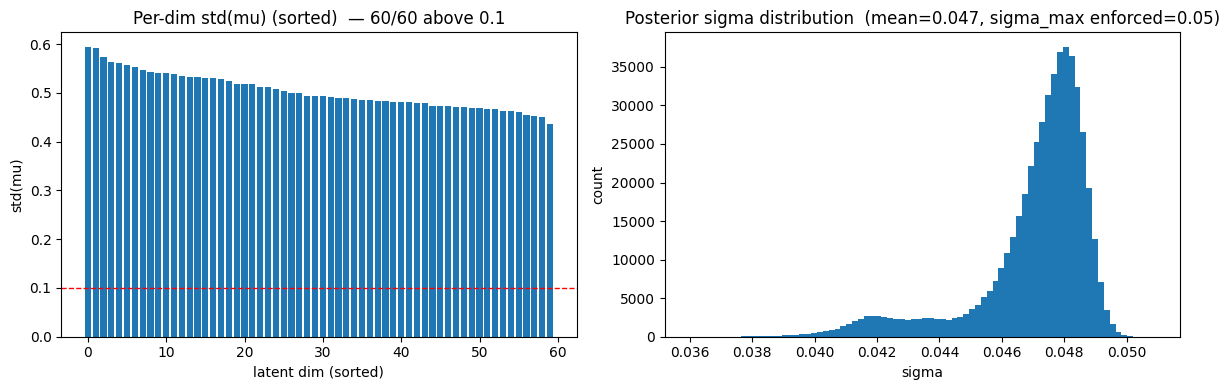

In [5]:
# How many latent dims are *used* (per-dim std of mu across all windows)?
per_dim_mu_std = z_means_all.std(0)
active_latents = int((per_dim_mu_std > 0.1).sum())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(np.arange(len(per_dim_mu_std)), np.sort(per_dim_mu_std)[::-1])
axes[0].axhline(0.1, ls="--", c="r", lw=1)
axes[0].set(
    title=f"Per-dim std(mu) (sorted)  — {active_latents}/{len(per_dim_mu_std)} above 0.1",
    xlabel="latent dim (sorted)",
    ylabel="std(mu)",
)
axes[1].hist(z_stds_all.flatten(), bins=80)
axes[1].set(
    title=f"Posterior sigma distribution  (mean={z_stds_all.mean():.3f}, sigma_max enforced=0.05)",
    xlabel="sigma",
    ylabel="count",
)
plt.tight_layout()
plt.show()

In [6]:
# Between / within class spread: is each behavior distinguishable?
behaviors = sorted(set(labels))
centroids = {b: z_means_all[labels == b].mean(0) for b in behaviors}
within = {b: z_means_all[labels == b].var(0).sum() for b in behaviors}
centroid_mat = np.stack([centroids[b] for b in behaviors], 0)
between_var = centroid_mat.var(0).sum()
avg_within = float(np.mean(list(within.values())))
ratio = between_var / max(avg_within, 1e-8)
print(f"between-class variance: {between_var:.3f}")
print(f"avg within-class var:   {avg_within:.3f}")
print(
    f"ratio (>1 = encoder discriminates classes; <<1 = pose-within-behavior dominates):  {ratio:.3f}"
)

# Pairwise centroid distances
print("\nPairwise centroid L2 distances:")
header = " " * 12 + "".join(f"{b:>11s}" for b in behaviors)
print(header)
for b1 in behaviors:
    row = f"{b1:12s}"
    for b2 in behaviors:
        row += f"{np.linalg.norm(centroids[b1]-centroids[b2]):11.3f}"
    print(row)

between-class variance: 1.431
avg within-class var:   14.178
ratio (>1 = encoder discriminates classes; <<1 = pose-within-behavior dominates):  0.101

Pairwise centroid L2 distances:
              FaceGroom   FastWalk     LGroom     RGroom       Rear       Walk
FaceGroom         0.000      1.778      1.316      1.930      1.670      1.694
FastWalk          1.778      0.000      2.061      2.135      1.274      0.642
LGroom            1.316      2.061      0.000      2.643      2.196      1.959
RGroom            1.930      2.135      2.643      0.000      2.208      1.940
Rear              1.670      1.274      2.196      2.208      0.000      1.449
Walk              1.694      0.642      1.959      1.940      1.449      0.000


PC1: 0.059, PC1+2: 0.115, PC1..5: 0.246


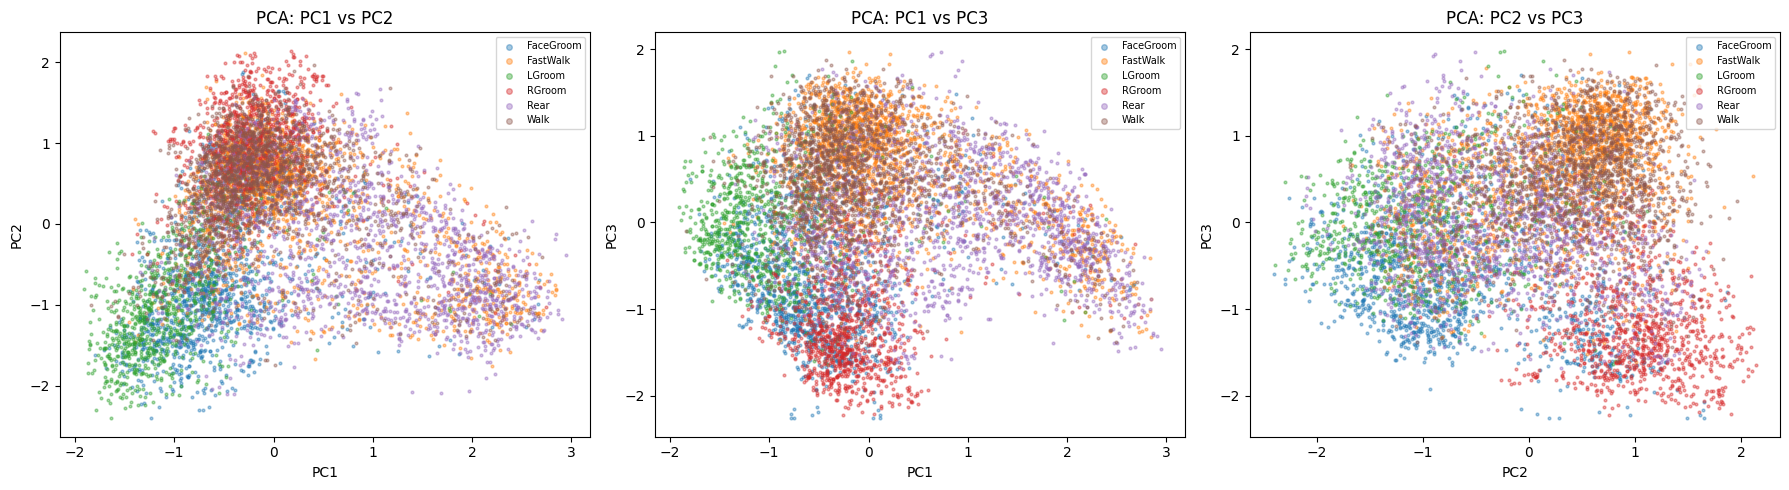

In [7]:
# PCA scatter of z_means colored by behavior.
Z = z_means_all - z_means_all.mean(0, keepdims=True)
U, S, Vt = np.linalg.svd(Z, full_matrices=False)
pcs = Z @ Vt[:3].T  # (N, 3)
var_ratio = (S**2) / (S**2).sum()
print(
    f"PC1: {var_ratio[0]:.3f}, PC1+2: {var_ratio[:2].sum():.3f}, PC1..5: {var_ratio[:5].sum():.3f}"
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
color_map = {b: plt.cm.tab10(i) for i, b in enumerate(behaviors)}
for b in behaviors:
    mask = labels == b
    for ax, (xi, yi) in zip(axes, [(0, 1), (0, 2), (1, 2)]):
        ax.scatter(
            pcs[mask, xi], pcs[mask, yi], s=4, alpha=0.4, color=color_map[b], label=b
        )
for ax, (xi, yi) in zip(axes, [(0, 1), (0, 2), (1, 2)]):
    ax.set(xlabel=f"PC{xi+1}", ylabel=f"PC{yi+1}", title=f"PCA: PC{xi+1} vs PC{yi+1}")
    ax.legend(loc="upper right", fontsize=7, markerscale=2)
plt.tight_layout()
plt.show()

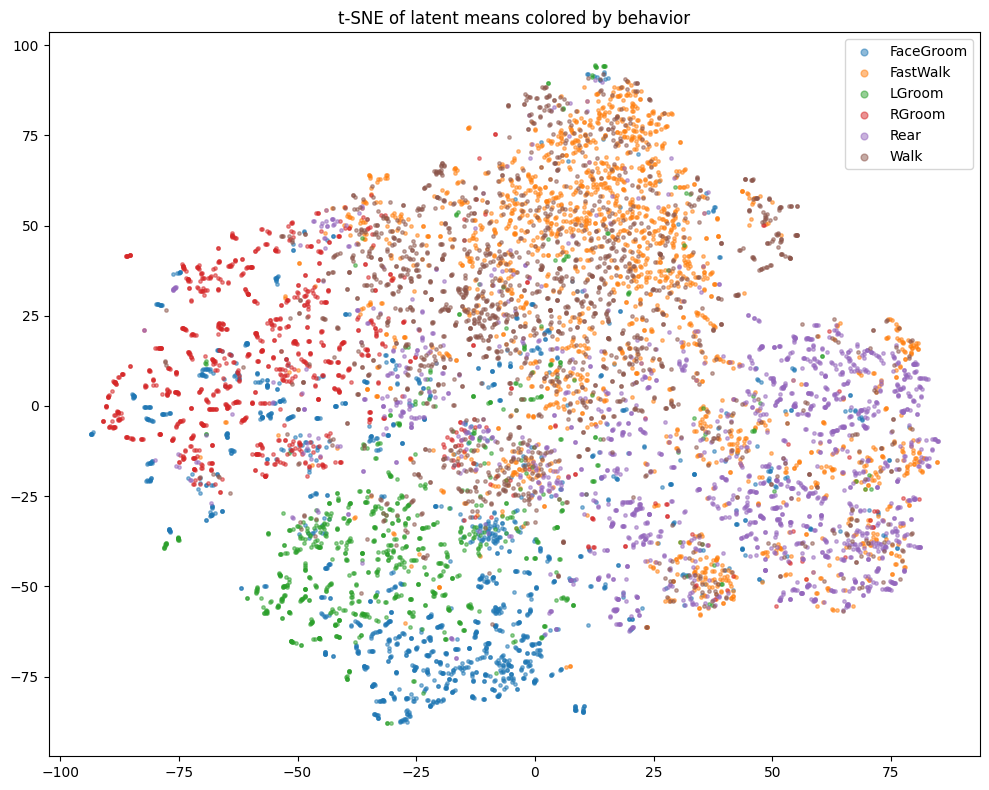

In [8]:
# t-SNE of z_means (matches paper's Fig 7).
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=0, init="pca")
z_2d = tsne.fit_transform(z_means_all)

plt.figure(figsize=(10, 8))
for b in behaviors:
    mask = labels == b
    plt.scatter(
        z_2d[mask, 0], z_2d[mask, 1], s=6, alpha=0.5, color=color_map[b], label=b
    )
plt.title("t-SNE of latent means colored by behavior")
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

## 3. Reconstruction quality

On the val split (last 20% of clips), run encode→decode and report:
- All-dim normalized MSE (the headline metric)
- Active-dim MSE (excludes dead zero-variance channels — the meaningful per-dim error)
- Per-feature-block breakdown (root_p, root_quat, joint q)

In [9]:
# Need to load the decoder for reconstruction.
feat_dim = prior.feat_dim
dec = MotionDecoder(
    layer_sizes=tuple(cfg.decoder_layer_sizes),
    window_len=prior.window_len,
    feat_dim=feat_dim,
)
rng = jax.random.PRNGKey(1)
dec_init = dec.init(rng, jnp.zeros((1, prior.latent_dim)))
with open(CKPT_DIR / "decoder.msgpack", "rb") as f:
    dec_params = serialization.from_bytes(dec_init, f.read())


@jax.jit
def encode_decode(enc_p, dec_p, x):
    mean, _ = prior.encoder.apply(enc_p, prior.normalize(x))
    return dec.apply(dec_p, mean), mean


# Build val split (matches Phase 1 training split: seed=0, train_ratio=0.8)
rng_np = np.random.default_rng(0)
perm = rng_np.permutation(motion_all.shape[0])
split = int(round(motion_all.shape[0] * 0.8))
val_motion = motion_all[perm[split:]]
val_in = np.concatenate(
    [
        np.stack([clip[a : a + w] for a in range(motion_all.shape[1] - w)], 0)
        for clip in val_motion
    ],
    0,
).astype(np.float32)
print(f"val windows: {val_in.shape}")

val windows: (40320, 10, 74)


In [10]:
# Encode-decode in chunks; compute per-dim residual
norm_mean = np.asarray(prior.normalizer.mean)
norm_std = np.asarray(prior.normalizer.std)
std_safe = np.maximum(norm_std, 1e-6)
val_in_n = (val_in - norm_mean) / std_safe

batch = 4096
sse_per_dim = np.zeros(feat_dim, dtype=np.float64)
n_elem = 0
for s in range(0, val_in_n.shape[0], batch):
    x = jnp.asarray(val_in_n[s : s + batch])
    recon_n, _ = encode_decode(prior.enc_params, dec_params, val_in[s : s + batch])
    err_n = (np.asarray(recon_n) - val_in_n[s : s + batch]) ** 2
    sse_per_dim += err_n.reshape(-1, feat_dim).sum(0)
    n_elem += err_n.reshape(-1, feat_dim).shape[0]
mse_per_dim = sse_per_dim / n_elem
all_dim_mse = mse_per_dim.mean()
active_dim_mse = (mse_per_dim * active_mask).sum() / active_mask.sum()
print(
    f"val_recon all-dim MSE:       {all_dim_mse:.4f}  ({100*(1-all_dim_mse):.1f}% var explained per dim)"
)
print(
    f"val_recon active-dim MSE:    {active_dim_mse:.4f}  ({100*(1-active_dim_mse):.1f}% var explained per active dim)"
)

# Per-feature-block breakdown (use_qvel=False: blocks are p, theta, q)
if not prior.use_qvel:
    blocks = [
        ("root_p (3)", slice(0, 3)),
        ("root_quat (4)", slice(3, 7)),
        ("joint q (67)", slice(7, 7 + prior.n_joints)),
    ]
else:
    nj = prior.n_joints
    blocks = [
        ("root_p (3)", slice(0, 3)),
        ("root_quat (4)", slice(3, 7)),
        ("root_v (6)", slice(7, 13)),
        ("joint q", slice(13, 13 + nj)),
        ("joint qdot", slice(13 + nj, 13 + 2 * nj)),
    ]
print("\nPer-block recon MSE:")
for name, sl in blocks:
    m = mse_per_dim[sl].mean()
    pct = max(0.0, 1.0 - m) * 100
    print(f"  {name:24s}: {m:.4f}  ({pct:.1f}% var explained)")

val_recon all-dim MSE:       0.3614  (63.9% var explained per dim)
val_recon active-dim MSE:    0.0189  (98.1% var explained per active dim)

Per-block recon MSE:
  root_p (3)              : 0.0064  (99.4% var explained)
  root_quat (4)           : 0.0096  (99.0% var explained)
  joint q (67)            : 0.3983  (60.2% var explained)


## 4. Predictor quality

**Single-step prediction** (the regime Phase 2 actually uses) vs **iterated autoregressive rollout** (stress test).

Phase 2 calls the predictor once per policy step on a fresh, real motion window — single-step is the relevant metric. Autoregressive is included only to show the latent dynamics are not self-consistent under feedback (expected for VAE without scheduled-sampling).

In [11]:
# Pick representative clips (one per behavior) for visualization.
def pick_representative(beh_name):
    idxs = np.where(behavior == beh_name)[0]
    motion_mag = [
        np.linalg.norm(np.diff(motion_all[i, :, :3], axis=0), axis=-1).sum()
        for i in idxs
    ]
    return int(idxs[np.argsort(motion_mag)[len(motion_mag) // 2]])


REP_CLIPS = {b: pick_representative(b) for b in behaviors}
print("Representative clip per behavior (median forward motion):")
for b, idx in REP_CLIPS.items():
    print(f"  {b:12s}: clip {idx}")

Representative clip per behavior (median forward motion):
  FaceGroom   : clip 36
  FastWalk    : clip 555
  LGroom      : clip 108
  RGroom      : clip 411
  Rear        : clip 575
  Walk        : clip 156


In [12]:
# Per-horizon-step prediction error (single-step, encoder always sees real history).
@jax.jit
def _predict_single(enc_p, pred_p, x):
    m, _ = prior.encoder.apply(enc_p, prior.normalize(x))
    return prior.predictor.apply(pred_p, m)


def per_horizon_mse(clip_idx):
    clip = motion_all[clip_idx]
    T = clip.shape[0]
    starts = np.arange(w, T - prior.horizon + 1)
    wins = np.stack([clip[a - w : a] for a in starts], 0)
    tgts = np.stack([clip[a : a + prior.horizon] for a in starts], 0)
    tgts_n = (tgts - norm_mean) / std_safe
    pred_n = np.asarray(
        _predict_single(prior.enc_params, prior.pred_params, jnp.asarray(wins))
    )
    per_step = []
    for k in range(prior.horizon):
        err = (pred_n[:, k] - tgts_n[:, k]) ** 2
        per_dim = err.mean(0)
        per_step.append(float((per_dim * active_mask).sum() / active_mask.sum()))
    return per_step


print(f"{'behavior':14s} " + " ".join(f"h={k+1}" for k in range(prior.horizon)))
for b, idx in REP_CLIPS.items():
    per = per_horizon_mse(idx)
    pcts = [f"{100*(1-x):.0f}%" for x in per]
    print(f"{b:14s} " + " ".join(f"{p:>4s}" for p in pcts))

behavior       h=1 h=2 h=3 h=4 h=5
FaceGroom       99%  98%  97%  96%  95%
FastWalk        99%  97%  96%  95%  94%
LGroom          98%  97%  95%  93%  92%
RGroom          99%  99%  98%  97%  95%
Rear            99%  99%  98%  97%  96%
Walk            99%  97%  96%  94%  92%


## 5. Render reconstruction + prediction videos

Loads the rat MuJoCo model and renders the reference motion vs the model's reconstruction or prediction. Three video styles per clip:

- **side-by-side**: reference (left) | model (right)
- **ghost overlay**: alpha-blend of reference (40%) + model (60%) — when motions match, looks like one rat; when they diverge, you see ghosting
- **single-step prediction**: encode real every frame, show the predictor's first predicted frame — the regime Phase 2 uses
- **autoregressive rollout** (stress test, will look bad): feed predictor's output back as next history

In [13]:
import imageio
import mujoco
from IPython.display import Video, display

# === Helpers ===


def feat_to_qpos(feat: np.ndarray, use_qvel: bool, n_joints: int) -> np.ndarray:
    """Convert reconstructed/predicted feat vector back to a 74-dim qpos."""
    if use_qvel:
        p, theta, q = feat[..., 0:3], feat[..., 3:7], feat[..., 13 : 13 + n_joints]
    else:
        p, theta, q = feat[..., 0:3], feat[..., 3:7], feat[..., 7 : 7 + n_joints]
    qpos = np.concatenate([p, theta, q], axis=-1)
    # decoder produces free-floating quaternions; renormalize to unit norm.
    quat = qpos[..., 3:7]
    n = np.linalg.norm(quat, axis=-1, keepdims=True)
    qpos[..., 3:7] = quat / np.maximum(n, 1e-8)
    return qpos


def reconstruct_clip(motion_clip):
    """Stride-1 sliding-window encode-decode + average overlapping recons."""
    T, _ = motion_clip.shape
    n_w = T - w + 1
    starts = np.arange(n_w)
    wins = motion_clip[starts[:, None] + np.arange(w)]
    win_n = (wins - norm_mean) / std_safe

    @jax.jit
    def step(x):
        m, _ = prior.encoder.apply(prior.enc_params, x)
        return dec.apply(dec_params, m)

    chunks = []
    bsz = 64
    for s in range(0, n_w, bsz):
        chunks.append(np.asarray(step(jnp.asarray(win_n[s : s + bsz]))))
    recon_n = np.concatenate(chunks, 0)
    recon = recon_n * std_safe + norm_mean
    out_sum = np.zeros((T, feat_dim), dtype=np.float64)
    out_cnt = np.zeros((T, 1), dtype=np.float64)
    for i, s in enumerate(starts):
        out_sum[s : s + w] += recon[i]
        out_cnt[s : s + w] += 1
    return (out_sum / out_cnt).astype(np.float32)


def predict_singlestep(motion_clip):
    """At each anchor t in [w, T), encode real [t-w:t], emit predicted frame at t."""
    T, _ = motion_clip.shape
    n_anchors = T - w
    starts = np.arange(n_anchors)
    wins = motion_clip[starts[:, None] + np.arange(w)]
    win_n = (wins - norm_mean) / std_safe

    @jax.jit
    def step(x):
        m, _ = prior.encoder.apply(prior.enc_params, x)
        return prior.predictor.apply(prior.pred_params, m)

    chunks = []
    bsz = 64
    for s in range(0, n_anchors, bsz):
        chunks.append(np.asarray(step(jnp.asarray(win_n[s : s + bsz]))))
    pred_n = np.concatenate(chunks, 0)
    pred = pred_n * std_safe + norm_mean
    out = np.zeros_like(motion_clip)
    out[:w] = motion_clip[:w]
    out[w:] = pred[:, 0]  # 1-step ahead prediction at each anchor
    return out


def predict_autoregressive(motion_clip):
    """Iterated rollout: feed predictor output back as next history. Drifts."""
    T, _ = motion_clip.shape
    h = prior.horizon
    out = np.zeros_like(motion_clip)
    out[:w] = motion_clip[:w]

    @jax.jit
    def step(x_n):
        m, _ = prior.encoder.apply(prior.enc_params, x_n)
        return prior.predictor.apply(prior.pred_params, m)

    cursor = w
    while cursor < T:
        x_n = (out[cursor - w : cursor] - norm_mean) / std_safe
        y_n = np.asarray(step(jnp.asarray(x_n[None])))[0]
        y = y_n * std_safe + norm_mean
        end = min(cursor + h, T)
        out[cursor:end] = y[: end - cursor]
        cursor = end
    return out


def render_qpos_seq(mj_model, qpos_seq, camera="side", height=480, width=640):
    data = mujoco.MjData(mj_model)
    renderer = mujoco.Renderer(mj_model, height=height, width=width)
    cam_id = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_CAMERA, camera)
    frames = np.empty((qpos_seq.shape[0], height, width, 3), dtype=np.uint8)
    for i, q in enumerate(qpos_seq):
        data.qpos[: mj_model.nq] = q
        mujoco.mj_forward(mj_model, data)
        renderer.update_scene(data, camera=cam_id)
        frames[i] = renderer.render()
    return frames


def overlay_pair(ref_frames, mod_frames, alpha_ref=0.4):
    a = np.float32(ref_frames) * alpha_ref + np.float32(mod_frames) * (1 - alpha_ref)
    return np.clip(a, 0, 255).astype(np.uint8)


def side_by_side(left, right):
    h = left.shape[1]
    sep = np.zeros((left.shape[0], h, 8, 3), dtype=np.uint8)
    return np.concatenate([left, sep, right], axis=2)


def write_video(frames, path, fps=50):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    imageio.mimsave(path, frames, fps=fps, codec="libx264", quality=8)
    return path


mj_model = mujoco.MjModel.from_xml_path(RAT_XML)
print(f"rat model loaded: nq={mj_model.nq}")

rat model loaded: nq=74


In [14]:
# Pick a behavior to render. Change this and re-run the cell to render others.
BEHAVIOR_TO_RENDER = "Walk"
CAMERA = "side"  # other options: 'close_profile', 'back', 'side_alt', 'top'

clip_idx = REP_CLIPS[BEHAVIOR_TO_RENDER]
label = f"clip{clip_idx:03d}_{BEHAVIOR_TO_RENDER}"
print(f"Rendering {label}...")

motion_clip = motion_all[clip_idx]
qpos_ref = np.asarray(clips.qpos[clip_idx], dtype=np.float32)

recon_feat = reconstruct_clip(motion_clip)
qpos_recon = feat_to_qpos(recon_feat, prior.use_qvel, prior.n_joints)

pred1_feat = predict_singlestep(motion_clip)
qpos_pred1 = feat_to_qpos(pred1_feat, prior.use_qvel, prior.n_joints)

predAR_feat = predict_autoregressive(motion_clip)
qpos_predAR = feat_to_qpos(predAR_feat, prior.use_qvel, prior.n_joints)

print("  rendering reference...")
ref_frames = render_qpos_seq(mj_model, qpos_ref, camera=CAMERA)
print("  rendering reconstruction...")
rec_frames = render_qpos_seq(mj_model, qpos_recon, camera=CAMERA)
print("  rendering single-step prediction...")
p1_frames = render_qpos_seq(mj_model, qpos_pred1, camera=CAMERA)
print("  rendering autoregressive rollout...")
pAR_frames = render_qpos_seq(mj_model, qpos_predAR, camera=CAMERA)

video_paths = {
    "recon_sxs": write_video(
        side_by_side(ref_frames, rec_frames), RENDER_DIR / f"recon_sxs_{label}.mp4"
    ),
    "recon_ghost": write_video(
        overlay_pair(ref_frames, rec_frames), RENDER_DIR / f"recon_ghost_{label}.mp4"
    ),
    "predict1step_sxs": write_video(
        side_by_side(ref_frames, p1_frames),
        RENDER_DIR / f"predict1step_sxs_{label}.mp4",
    ),
    "predict1step_ghost": write_video(
        overlay_pair(ref_frames, p1_frames),
        RENDER_DIR / f"predict1step_ghost_{label}.mp4",
    ),
    "predictAR_sxs": write_video(
        side_by_side(ref_frames, pAR_frames), RENDER_DIR / f"predictAR_sxs_{label}.mp4"
    ),
    "predictAR_ghost": write_video(
        overlay_pair(ref_frames, pAR_frames),
        RENDER_DIR / f"predictAR_ghost_{label}.mp4",
    ),
}
for k, p in video_paths.items():
    print(f"  {k:20s}: {p}")

Rendering clip156_Walk...
  rendering reference...
  rendering reconstruction...
  rendering single-step prediction...
  rendering autoregressive rollout...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1288, 480) to (1296, 480) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
/home/talmolab/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1288, 480) to (1296, 480) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_b

  recon_sxs           : /home/talmolab/Desktop/SalkResearch/track-mjx/checkpoints/latent_prior_v8/best/renders/recon_sxs_clip156_Walk.mp4
  recon_ghost         : /home/talmolab/Desktop/SalkResearch/track-mjx/checkpoints/latent_prior_v8/best/renders/recon_ghost_clip156_Walk.mp4
  predict1step_sxs    : /home/talmolab/Desktop/SalkResearch/track-mjx/checkpoints/latent_prior_v8/best/renders/predict1step_sxs_clip156_Walk.mp4
  predict1step_ghost  : /home/talmolab/Desktop/SalkResearch/track-mjx/checkpoints/latent_prior_v8/best/renders/predict1step_ghost_clip156_Walk.mp4
  predictAR_sxs       : /home/talmolab/Desktop/SalkResearch/track-mjx/checkpoints/latent_prior_v8/best/renders/predictAR_sxs_clip156_Walk.mp4
  predictAR_ghost     : /home/talmolab/Desktop/SalkResearch/track-mjx/checkpoints/latent_prior_v8/best/renders/predictAR_ghost_clip156_Walk.mp4


In [15]:
# Embed videos inline. Order: recon side-by-side, single-step prediction, AR rollout.
print(f"== {BEHAVIOR_TO_RENDER} (clip {clip_idx}) ==")
print(
    "1. Reconstruction (left=reference, right=model). The encoder+decoder fidelity test."
)
display(Video(video_paths["recon_sxs"], embed=True, html_attributes="controls loop"))
print(
    "\n2. Single-step prediction (left=reference, right=1-step-ahead from real history)."
)
print("   This is the operating mode Phase 2 will use. Should be close to reference.")
display(
    Video(video_paths["predict1step_sxs"], embed=True, html_attributes="controls loop")
)
print(
    "\n3. Autoregressive rollout (left=reference, right=iterated prediction). Stress test —"
)
print(
    "   feedback loop diverges fast for VAEs without scheduled-sampling. Phase 2 does NOT use this."
)
display(
    Video(video_paths["predictAR_sxs"], embed=True, html_attributes="controls loop")
)

== Walk (clip 156) ==
1. Reconstruction (left=reference, right=model). The encoder+decoder fidelity test.



2. Single-step prediction (left=reference, right=1-step-ahead from real history).
   This is the operating mode Phase 2 will use. Should be close to reference.



3. Autoregressive rollout (left=reference, right=iterated prediction). Stress test —
   feedback loop diverges fast for VAEs without scheduled-sampling. Phase 2 does NOT use this.


In [16]:
# Ghost overlays for the same clip (40% reference + 60% model).
print("Ghost overlays (transparent ref + solid model):")
print("Reconstruction overlay:")
display(Video(video_paths["recon_ghost"], embed=True, html_attributes="controls loop"))
print("Single-step prediction overlay:")
display(
    Video(
        video_paths["predict1step_ghost"], embed=True, html_attributes="controls loop"
    )
)

Ghost overlays (transparent ref + solid model):
Reconstruction overlay:


Single-step prediction overlay:


### Render all 6 behaviors at once (heavier)

Uncomment the cell below to render all six behaviors in a sweep. Each behavior produces 6 videos, so it'll write 36 mp4s (~30 MB total) and take ~10 minutes.

In [17]:
# # Sweep all behaviors. Uncomment to run.
# for b, idx in REP_CLIPS.items():
#     label = f'clip{idx:03d}_{b}'
#     print(f'=== {label} ===')
#     mc = motion_all[idx]
#     qref = np.asarray(clips.qpos[idx], dtype=np.float32)
#     qrec = feat_to_qpos(reconstruct_clip(mc), prior.use_qvel, prior.n_joints)
#     qp1  = feat_to_qpos(predict_singlestep(mc), prior.use_qvel, prior.n_joints)
#     qpAR = feat_to_qpos(predict_autoregressive(mc), prior.use_qvel, prior.n_joints)
#     ref_f = render_qpos_seq(mj_model, qref, camera=CAMERA)
#     rec_f = render_qpos_seq(mj_model, qrec, camera=CAMERA)
#     p1_f  = render_qpos_seq(mj_model, qp1,  camera=CAMERA)
#     pAR_f = render_qpos_seq(mj_model, qpAR, camera=CAMERA)
#     write_video(side_by_side(ref_f, rec_f), RENDER_DIR / f'recon_sxs_{label}.mp4')
#     write_video(overlay_pair(ref_f, rec_f), RENDER_DIR / f'recon_ghost_{label}.mp4')
#     write_video(side_by_side(ref_f, p1_f),  RENDER_DIR / f'predict1step_sxs_{label}.mp4')
#     write_video(overlay_pair(ref_f, p1_f),  RENDER_DIR / f'predict1step_ghost_{label}.mp4')
#     write_video(side_by_side(ref_f, pAR_f), RENDER_DIR / f'predictAR_sxs_{label}.mp4')
#     write_video(overlay_pair(ref_f, pAR_f), RENDER_DIR / f'predictAR_ghost_{label}.mp4')
#     print(f'  6 videos written for {b}')

## Summary

What to look for as you read through this notebook:

- **§2 latent organization**: between/within ratio, pairwise centroid distances, t-SNE structure. For Phase 2's `r_mimic` to give meaningful gradient signal, the encoder must produce distinguishable z's for different motion *segments* (not necessarily different *behaviors*). The within-class spread can be larger than between-class — that's the normal VAE-on-mocap pattern (see paper Fig 7 — continuous loops per gait).
- **§3 reconstruction**: active-dim MSE under ~0.05 (= 95% var explained per active dim) means the encoder retains enough information to reconstruct.
- **§4 predictor**: single-step (h=1) MSE near 0.01 (~99%) is the **only** Phase 2-relevant metric. AR rollout failing is expected and orthogonal.
- **§5 videos**: the reconstruction render should look essentially indistinguishable from reference. The single-step prediction render should look very close to reference (you should see almost no ghosting in the overlay). The AR rollout will be a tumbling rat — that's expected, the predictor wasn't trained for autoregressive use.